In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import datetime as dt
%matplotlib inline
import os
import sys
from tqdm import tqdm
sys.path.append('/home/drdarby/Desktop/cape_mend_SM_LCS/datatools')
from datatools import datatools as tools        

In [3]:
data_path = '../../../../mnt/thesis_model_data/Data/LLC4320/norcal_surf/'

variables = ['Eta','Theta','Salt','U','V','W','oceTAUX','oceTAUY']
path_tohd = '/media/basil/Elements/data/Thesis/LLC4320/nc_files/'

In [4]:
for var in variables:
    os.system('mkdir '+path_tohd+var)

mkdir: cannot create directory ‘/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/Eta’: No such file or directory
mkdir: cannot create directory ‘/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/Theta’: No such file or directory
mkdir: cannot create directory ‘/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/Salt’: No such file or directory
mkdir: cannot create directory ‘/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/U’: No such file or directory
mkdir: cannot create directory ‘/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/V’: No such file or directory
mkdir: cannot create directory ‘/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/W’: No such file or directory
mkdir: cannot create directory ‘/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/oceTAUX’: No such file or directory
mkdir: cannot create directory ‘/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/oceTAUY’: No such file or directory


In [12]:
j0 = np.arange(672)
i0 = np.arange(1486)
dim = ['time','i','j']
location = (0,10)
for j in range(2,len(variables)):
    data_files, data_filepath = tools.get_data_paths_from_binary(data_path,variables[j])
    current_files, current_filepaths = tools.get_data_paths_from_binary(path_tohd,variables[j],file_end='nc')
    for i in tqdm(range(len(current_files),len(data_files))):
        time_itter=data_files[i][location[0]:location[1]]
        output = path_tohd+variables[j]+'/'
        output_file = variables[j]+'_'+time_itter+'.nc'
        time = [tools.convert_itter_to_datetime(time_itter,datetime(2011,9,10),25)]
        shape = (len(time),len(i0),len(j0))
        cord = [time, i0, j0]

        tools.convert_binary_to_nc(data_files[i],data_filepath[i],shape,dim,cord,variables[j],output_filepath='./'+output_file)
        os.system('mv '+'./'+output_file+' '+ output)

100%|█████████████████████████████████████| 9121/9121 [3:46:03<00:00,  1.49s/it]
0it [00:00, ?it/s]
100%|█████████████████████████████████████| 9121/9121 [3:41:42<00:00,  1.46s/it]


In [11]:
current_files, current_filepaths = tools.get_data_paths_from_binary(path_tohd,variables[3],file_end='nc')
len(current_files)

0

In [ ]:
# Same for grid file
os.system('mkdir '+path_tohd+'grid')
data_path = '/mnt/thesis_model_data/Data/LLC4320/norcal_surf/grid'

dim_of_grid=(672,1486,1)
tools.convert_mitgcm_grid_to_nc(data_path,dim_of_grid,output_path='./cape_mend_grid_llc4320.nc')
os.system('mv ./cape_mend_grid_llc4320.nc ./data/')

### Case Studies

In [2]:
path_model = '/media/drdarby/Elements/data/Thesis/LLC4320/Case_Studies/LLC4320/'

In [9]:
case_study_from= ['filament/','summer_eddy/']

In [10]:
case_study_to = ['fil/','eddy/']

In [6]:
output_path = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/cutouts/case_studies/' #eddy, fil

In [7]:
variables = ['Theta','Salt','U','V','W']

In [43]:
#filament
j0 = np.arange(163)
i0 = np.arange(173)
k=np.arange(84)
dim = ['time','k','i','j']
location = (0,10)
for j in range(1,len(variables)):
    data_files, data_filepath = tools.get_data_paths_from_binary(path_model+case_study_from[0],variables[j],file_end='84')
    current_files, current_filepaths = tools.get_data_paths_from_binary(output_path+case_study_to[0],variables[j],file_end='nc')
    for i in tqdm(range(len(current_files),len(data_files))):
        time_itter=data_files[i][location[0]:location[1]]
        output_file = variables[j]+'_'+time_itter+'.nc'
        time = [tools.convert_itter_to_datetime(time_itter,datetime(2011,9,10),25)]
        shape = (len(time),len(k),len(i0),len(j0))
        cord = [time,k, i0, j0]

        tools.convert_binary_to_nc(data_files[i],data_filepath[i],shape,dim,cord,variables[j],output_filepath=output_path+case_study_to[0]+variables[j]+'/'+output_file)


100%|█████████████████████████████████████████| 721/721 [03:37<00:00,  3.31it/s]


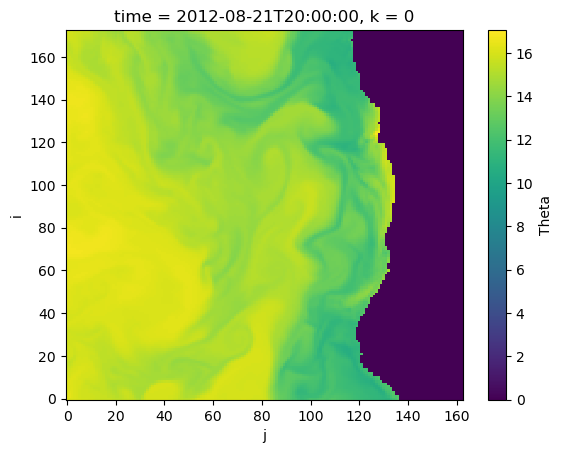

In [18]:
current_files, current_filepaths = tools.get_data_paths_from_binary(output_path+case_study_to[0],variables[0],file_end='nc')
theta = xr.open_mfdataset(current_filepaths)


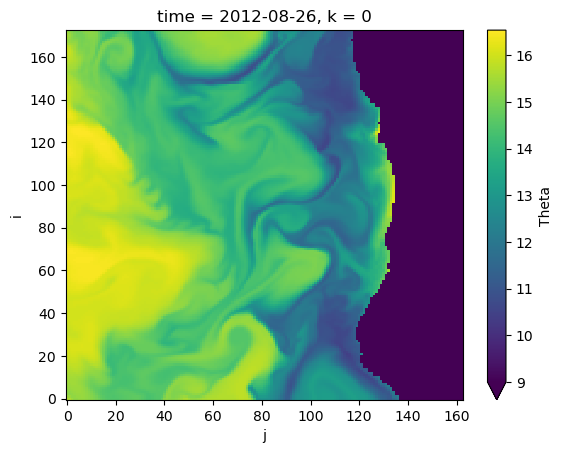

In [42]:
theta.isel(time=600,k=0)['Theta'].plot(vmin=9)

In [13]:
location = (0,10)
time_itter=data_files[0][location[0]:location[1]]
time = [tools.convert_itter_to_datetime(time_itter,datetime(2011,9,10),25)]
time

[datetime.datetime(2012, 8, 1, 0, 0)]

In [52]:
#summer_eddy
j0 = np.arange(96)
i0 = np.arange(114)
k=np.arange(81)
dim = ['time','k','i','j']
location = (0,10)
for j in range(0,len(variables)):
    data_files, data_filepath = tools.get_data_paths_from_binary(path_model+case_study_from[1],variables[j],file_end='81')
    current_files, current_filepaths = tools.get_data_paths_from_binary(output_path+case_study_to[1],variables[j],file_end='nc')
    for i in tqdm(range(len(current_files),len(data_files))):
        time_itter=data_files[i][location[0]:location[1]]
        output_file = variables[j]+'_'+time_itter+'.nc'
        time = [tools.convert_itter_to_datetime(time_itter,datetime(2011,9,10),25)]
        shape = (len(time),len(k),len(i0),len(j0))
        cord = [time,k, i0, j0]

        tools.convert_binary_to_nc(data_files[i],data_filepath[i],shape,dim,cord,variables[j],output_filepath=output_path+case_study_to[1]+variables[j]+'/'+output_file)

100%|███████████████████████████████████████| 1369/1369 [03:25<00:00,  6.65it/s]


In [48]:
current_files, current_filepaths = tools.get_data_paths_from_binary(output_path+case_study_to[1],variables[1],file_end='nc')
theta = xr.open_mfdataset(current_filepaths)

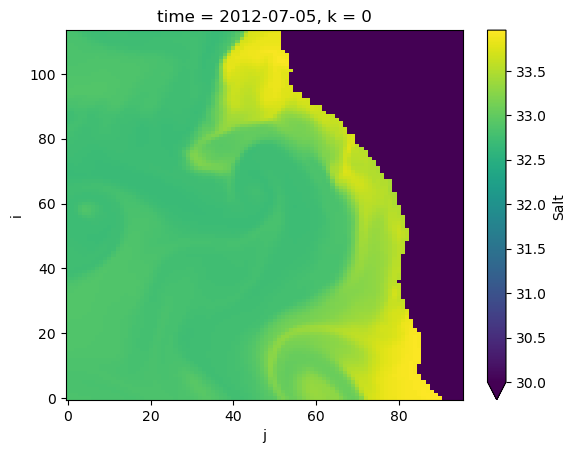

In [51]:
theta.isel(time=0,k=0)['Salt'].plot(vmin=30)